In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Data Import and Initial Inspection

This Colab version asks you to upload the supplied ZIP archive. The CSV is then read directly from the ZIP, so you do **not** need to extract it manually.


In [2]:
# Google Colab dataset upload
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

ZIP_PATH = Path("globalpowerplantdatabasev130.zip")
CSV_NAME = "global_power_plant_database.csv"

if IN_COLAB and not ZIP_PATH.exists():
    print("Upload globalpowerplantdatabasev130.zip when the file chooser appears.")
    uploaded = files.upload()
    zip_files = [name for name in uploaded if name.lower().endswith(".zip")]
    if not zip_files:
        raise FileNotFoundError("No ZIP file was uploaded. Please run this cell again and select the dataset ZIP.")
    ZIP_PATH = Path(zip_files[0])

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Could not find {ZIP_PATH}. Put the dataset ZIP in the same folder as the notebook.")

with zipfile.ZipFile(ZIP_PATH) as z:
    with z.open(CSV_NAME) as f:
        df = pd.read_csv(f, low_memory=False)

print(f"Loaded: {ZIP_PATH.name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Upload globalpowerplantdatabasev130.zip when the file chooser appears.


Saving globalpowerplantdatabasev130.zip to globalpowerplantdatabasev130.zip
Loaded: globalpowerplantdatabasev130.zip
Rows: 34,936
Columns: 36


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,other_fuel3,commissioning_year,owner,source,url,geolocation_source,wepp_id,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,generation_data_source,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.32,65.12,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009793,"2,017.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.00,31.67,65.80,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.00,31.62,65.79,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.56,69.48,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009795,"2,017.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.64,69.72,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009797,"2,017.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Column names:
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']

Data types:


,dtype
country,object
country_long,object
name,object
gppd_idnr,object
capacity_mw,float64
latitude,float64
longitude,float64
primary_fuel,object
other_fuel1,object
other_fuel2,object


## 2. Data Cleaning and Missing Values

Missing values are not all the same kind of problem. For example, a missing `commissioning_year` means the year is unknown, while missing generation values often mean generation was not reported for that plant and year. Replacing these with zero would create false information, so those fields remain `NaN` and are excluded only when a calculation requires them.

For analysis-critical numeric columns, `pd.to_numeric(..., errors="coerce")` is used so invalid text would become `NaN` instead of breaking calculations. NumPy is used to check ranges and build vectorized categories.


In [4]:
# Duplicate check
print("Exact duplicate rows:", df.duplicated().sum())

# Missing-value summary
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing.head(20))


Exact duplicate rows: 0


,missing_count,missing_percent
other_fuel3,34844,99.74
other_fuel2,34660,99.21
other_fuel1,32992,94.44
generation_gwh_2013,28519,81.63
generation_gwh_2014,27710,79.32
generation_gwh_2015,26733,76.52
generation_gwh_2016,25792,73.83
generation_gwh_2017,25436,72.81
generation_gwh_2018,25299,72.42
generation_gwh_2019,25277,72.35


In [5]:
# Make sure important quantitative columns are numeric.
numeric_cols = [
    "capacity_mw", "latitude", "longitude", "commissioning_year",
    "year_of_capacity_data"
] + [f"generation_gwh_{y}" for y in range(2013, 2020)] \
  + [f"estimated_generation_gwh_{y}" for y in range(2013, 2018)]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Basic validity checks using NumPy/Pandas vectorized operations.
valid_lat = np.logical_and(df["latitude"] >= -90, df["latitude"] <= 90)
valid_lon = np.logical_and(df["longitude"] >= -180, df["longitude"] <= 180)
positive_capacity = df["capacity_mw"] > 0

print("Valid latitude values:", f"{valid_lat.mean()*100:.2f}%")
print("Valid longitude values:", f"{valid_lon.mean()*100:.2f}%")
print("Positive capacity values:", f"{positive_capacity.mean()*100:.2f}%")

# Vectorized capacity categories with NumPy.
conditions = [
    df["capacity_mw"] < 10,
    df["capacity_mw"] < 100,
    df["capacity_mw"] < 1000
]
choices = ["Small (<10 MW)", "Medium (10–99 MW)", "Large (100–999 MW)"]
df["capacity_class"] = np.select(conditions, choices, default="Very large (1000+ MW)")

display(df["capacity_class"].value_counts().to_frame("plants"))


Valid latitude values: 100.00%
Valid longitude values: 100.00%
Positive capacity values: 100.00%


,plants
capacity_class,
Small (<10 MW),13599
Medium (10–99 MW),13505
Large (100–999 MW),6214
Very large (1000+ MW),1618


### Cleaning decision

No rows are deleted simply because optional fields are missing. Essential columns for the main analysis (`country_long`, `primary_fuel`, and `capacity_mw`) are complete in this version of the dataset. Analyses involving commissioning year or annual generation use only the non-missing observations required for that specific calculation.


## 3. Exploratory Data Analysis

First, summarize the main numerical attributes. Both **mean** and **median** are useful because power-plant capacity is strongly right-skewed: there are many small facilities and a much smaller number of extremely large plants.


In [6]:
summary_cols = ["capacity_mw", "latitude", "longitude", "commissioning_year"]
summary = df[summary_cols].agg(["count", "mean", "median", "std", "min", "max"]).T
summary.columns = ["count", "mean", "median", "std", "min", "max"]
display(summary)


,count,mean,median,std,min,max
capacity_mw,"34,936.00",163.36,16.74,489.64,1.00,"22,500.00"
latitude,"34,936.00",32.82,39.73,22.64,-77.85,71.29
longitude,"34,936.00",-6.97,-2.13,78.41,-179.98,179.39
commissioning_year,"17,447.00","1,997.41","2,007.00",23.40,"1,896.00","2,020.00"


In [7]:
country_counts = df["country_long"].value_counts()
fuel_counts = df["primary_fuel"].value_counts()

print("Top countries by number of plants:")
display(country_counts.head(10).to_frame("plant_count"))

print("Fuel types by number of plants:")
display(fuel_counts.to_frame("plant_count"))


Top countries by number of plants:


,plant_count
country_long,
United States of America,9833
China,4235
United Kingdom,2751
Brazil,2360
France,2155
India,1589
Germany,1309
Canada,1159
Spain,829


Fuel types by number of plants:


,plant_count
primary_fuel,
Solar,10665
Hydro,7156
Wind,5344
Gas,3998
Coal,2330
Oil,2320
Biomass,1430
Waste,1068
Nuclear,195


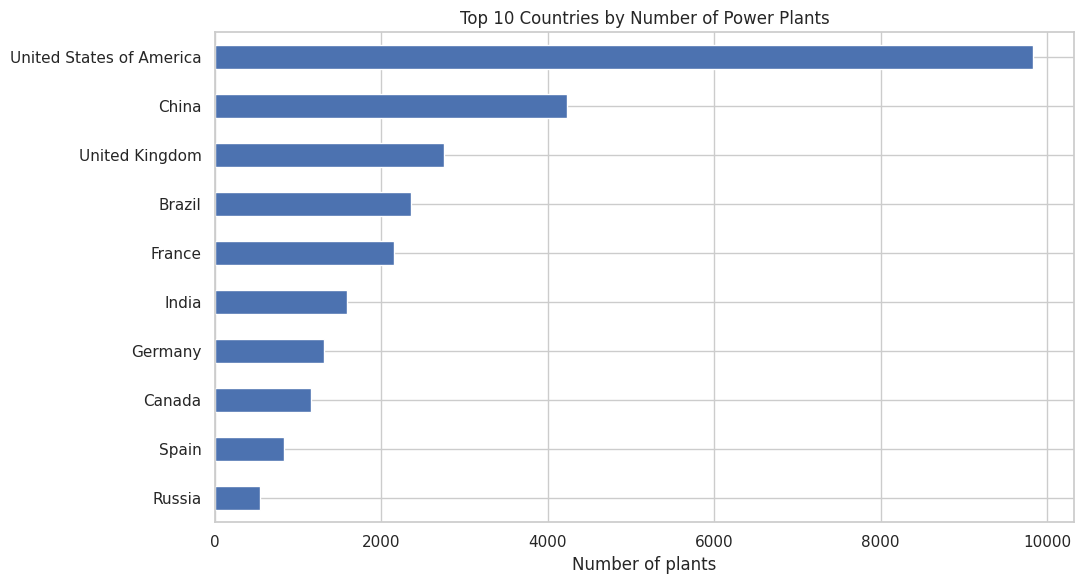

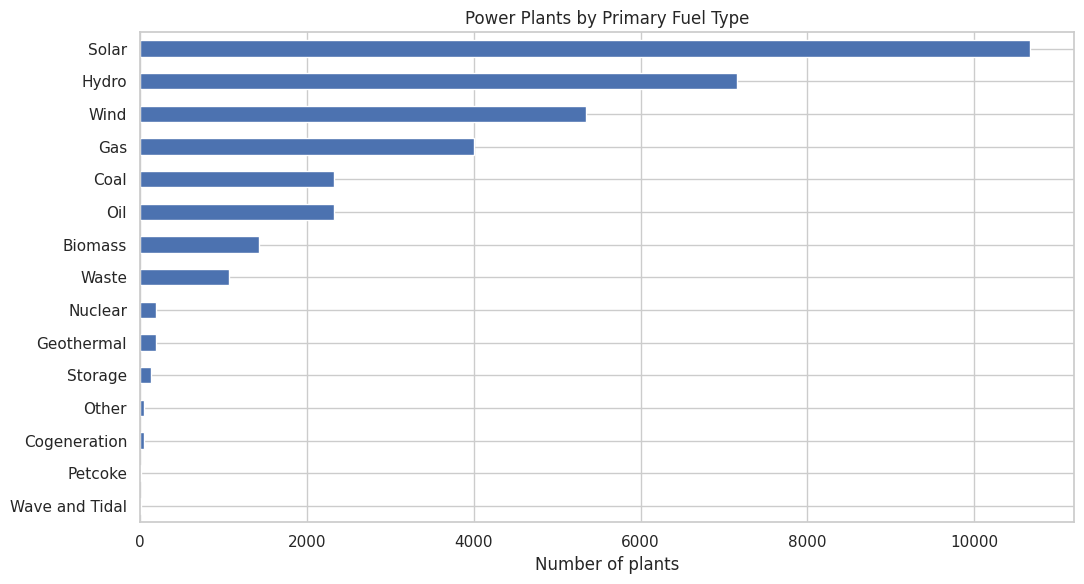

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
country_counts.head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 10 Countries by Number of Power Plants")
ax.set_xlabel("Number of plants")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
fuel_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Power Plants by Primary Fuel Type")
ax.set_xlabel("Number of plants")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Capacity by fuel type

Plant count and installed capacity tell different stories. Solar has the largest number of individual plants in the database, but coal, gas, hydro, and nuclear facilities tend to be much larger per site.


In [9]:
capacity_by_fuel = (
    df.groupby("primary_fuel")["capacity_mw"]
      .agg(["count", "mean", "median", "std", "sum"])
      .sort_values("mean", ascending=False)
)
display(capacity_by_fuel)


,count,mean,median,std,sum
primary_fuel,,,,,
Nuclear,195,"2,091.86","1,888.00","1,303.51","407,911.76"
Coal,2330,843.58,600.00,888.19,"1,965,541.00"
Gas,3998,373.45,147.50,560.93,"1,493,050.60"
Petcoke,12,202.05,65.49,476.99,"2,424.58"
Hydro,7156,147.17,20.00,549.81,"1,053,159.62"
Oil,2320,112.88,9.00,392.01,"261,878.71"
Cogeneration,41,98.73,31.90,283.43,"4,048.00"
Other,43,84.02,40.00,145.89,"3,612.86"
Geothermal,189,67.13,30.00,114.64,"12,687.75"


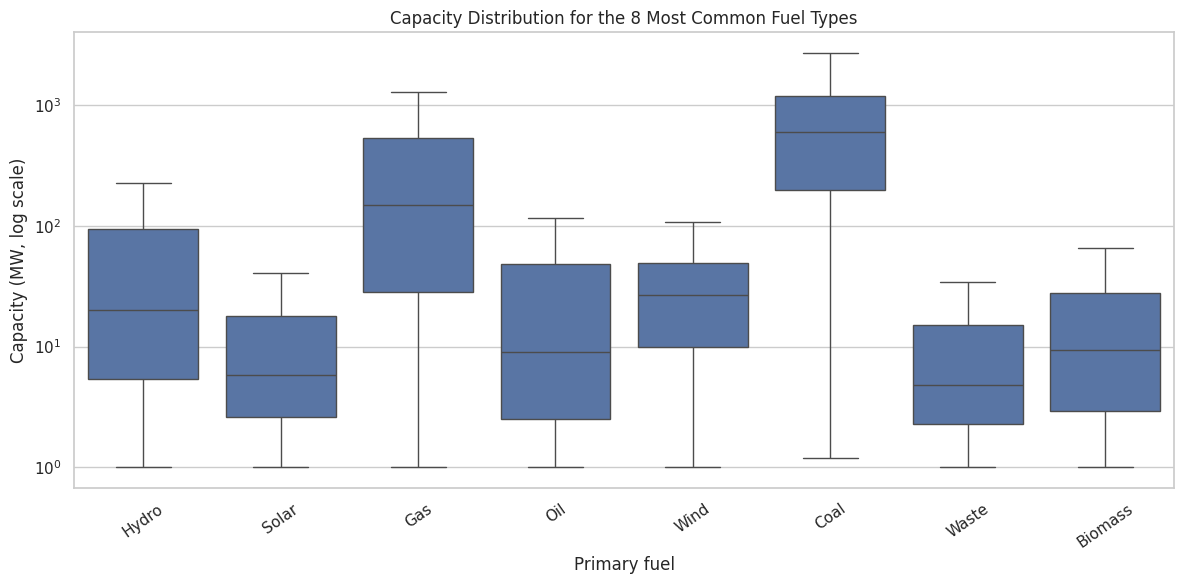

In [10]:
# A log scale makes the strongly skewed capacity distributions easier to compare.
top8 = fuel_counts.head(8).index
plot_df = df[df["primary_fuel"].isin(top8)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="primary_fuel", y="capacity_mw", showfliers=False)
plt.yscale("log")
plt.title("Capacity Distribution for the 8 Most Common Fuel Types")
plt.xlabel("Primary fuel")
plt.ylabel("Capacity (MW, log scale)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


## 4. Statistical Analysis and Hypothesis Testing

### Question
**Does average installed capacity differ among fuel types?**

- **Null hypothesis (H₀):** mean installed capacity is equal across fuel types.
- **Alternative hypothesis (H₁):** at least one fuel type has a different mean capacity.

A one-way ANOVA is shown because the assignment asks about differences in means. Because capacity is highly skewed and variances differ, a **Kruskal–Wallis** test is also included as a non-parametric robustness check. Only fuel groups with at least 100 observations are used in the multi-group tests.


In [11]:
major_fuels = fuel_counts[fuel_counts >= 100].index.tolist()
groups = [df.loc[df["primary_fuel"] == fuel, "capacity_mw"].dropna().to_numpy()
          for fuel in major_fuels]

anova = stats.f_oneway(*groups)
kruskal = stats.kruskal(*groups)

# ANOVA effect size: eta-squared
anova_df = df[df["primary_fuel"].isin(major_fuels)][["primary_fuel", "capacity_mw"]].dropna()
grand_mean = anova_df["capacity_mw"].mean()
ss_between = sum(
    len(g) * (g.mean() - grand_mean) ** 2
    for g in groups
)
ss_total = ((anova_df["capacity_mw"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total

print(f"Fuel groups tested: {len(major_fuels)}")
print(f"ANOVA F = {anova.statistic:,.2f}, p = {anova.pvalue:.3e}")
print(f"Kruskal-Wallis H = {kruskal.statistic:,.2f}, p = {kruskal.pvalue:.3e}")
print(f"Eta-squared = {eta_squared:.3f}")


Fuel groups tested: 11
ANOVA F = 1,351.66, p = 0.000e+00
Kruskal-Wallis H = 11,250.84, p = 0.000e+00
Eta-squared = 0.280


In [12]:
# Example pairwise comparison: Coal vs Gas using Welch's t-test.
coal = df.loc[df["primary_fuel"] == "Coal", "capacity_mw"].to_numpy()
gas = df.loc[df["primary_fuel"] == "Gas", "capacity_mw"].to_numpy()

welch = stats.ttest_ind(coal, gas, equal_var=False)

print(f"Coal mean capacity: {coal.mean():,.1f} MW (n={len(coal):,})")
print(f"Gas mean capacity:  {gas.mean():,.1f} MW (n={len(gas):,})")
print(f"Welch t = {welch.statistic:,.2f}, p = {welch.pvalue:.3e}")


Coal mean capacity: 843.6 MW (n=2,330)
Gas mean capacity:  373.4 MW (n=3,998)
Welch t = 23.01, p = 4.104e-109


### Interpretation

The p-values are far below 0.05, so the null hypothesis is rejected. Installed capacity differs significantly across fuel types. The eta-squared value indicates that fuel category explains a meaningful portion of the observed variation in plant capacity, although fuel type is not the only factor.

The Coal vs Gas Welch test provides a concrete pairwise example and also rejects equal means. Statistical significance here is unsurprising with a large dataset, so the size and practical meaning of the differences should be considered alongside p-values.


## 5. Time Series / Commissioning-Year Analysis

The database contains `commissioning_year`, but it is missing for many plants. Rather than inventing years, the time analysis uses only plants with a reported year between 1800 and 2026. Plants are grouped by decade to reduce noise and make changes in the fuel mix easier to interpret.


In [13]:
time_df = df[df["commissioning_year"].between(1800, 2026)].copy()
time_df["commissioning_year"] = time_df["commissioning_year"].astype(int)
time_df["decade"] = (time_df["commissioning_year"] // 10) * 10

print(f"Plants with usable commissioning year: {len(time_df):,} of {len(df):,} "
      f"({len(time_df)/len(df)*100:.1f}%)")
print(f"Earliest reported year: {time_df['commissioning_year'].min()}")
print(f"Latest reported year: {time_df['commissioning_year'].max()}")
print(f"Median commissioning year: {time_df['commissioning_year'].median():.0f}")

display(time_df["decade"].value_counts().sort_index().tail(12).to_frame("plant_count"))


Plants with usable commissioning year: 17,447 of 34,936 (49.9%)
Earliest reported year: 1896
Latest reported year: 2020
Median commissioning year: 2007


,plant_count
decade,
1910,144
1920,288
1930,189
1940,227
1950,551
1960,786
1970,952
1980,1455
1990,1628


In [14]:
# Fuel mix by decade, expressed as percent of plants with known commissioning year.
mix_pct = pd.crosstab(time_df["decade"], time_df["primary_fuel"], normalize="index") * 100
selected_decades = [d for d in [1960, 1970, 1980, 1990, 2000, 2010, 2020] if d in mix_pct.index]
display(mix_pct.loc[selected_decades].round(1))


primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wind
decade,,,,,,,,,,,,,,
1960,2.50,13.40,0.10,18.10,0.40,51.10,0.10,13.20,0.30,0.00,0.00,0.00,0.80,0.00
1970,2.90,18.50,0.30,23.10,0.70,29.70,3.60,19.70,0.00,0.20,0.00,0.00,1.10,0.10
1980,3.50,14.00,0.50,19.20,1.90,36.80,3.30,10.70,0.30,0.40,0.30,0.00,7.10,1.90
1990,3.70,14.10,0.50,30.20,2.60,22.80,0.30,14.80,0.20,0.10,0.10,0.00,6.30,4.30
2000,5.80,14.40,0.20,23.70,0.90,12.00,0.20,12.60,0.10,0.00,1.60,0.10,5.60,22.90
2010,2.70,7.80,0.10,7.90,0.40,7.30,0.10,5.50,0.10,0.00,46.30,1.40,2.90,17.60
2020,0.70,0.00,0.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,81.30,1.30,1.30,11.30


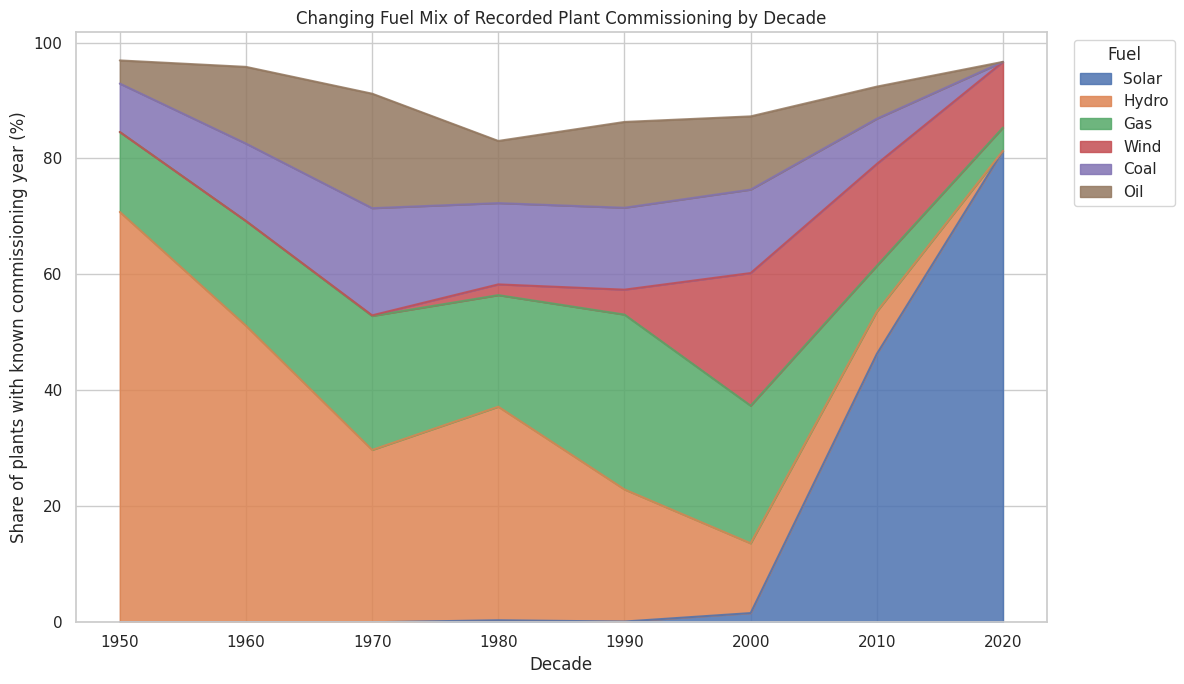

In [15]:
# Plot the six most common fuels among plants with commissioning-year data.
recent = time_df[time_df["decade"] >= 1950]
top_time_fuels = recent["primary_fuel"].value_counts().head(6).index
mix_top = pd.crosstab(recent["decade"], recent["primary_fuel"], normalize="index") * 100
mix_top = mix_top[top_time_fuels]

ax = mix_top.plot(kind="area", stacked=True, figsize=(12, 7), alpha=0.85)
ax.set_title("Changing Fuel Mix of Recorded Plant Commissioning by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of plants with known commissioning year (%)")
ax.legend(title="Fuel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Time-trend interpretation

Among plants with known commissioning years, hydro dominates many older decades, while wind and especially solar become much more prominent among plants commissioned in the 2000s and 2010s. This is evidence of a changing **plant mix**, not a direct measurement of global electricity generation. The 2020 decade is only a small partial sample in this database and should not be treated as a complete decade.


## 6. Advanced Visualization: Geographic Distribution

Latitude and longitude make it possible to visualize the global distribution of facilities without a separate geographic mapping library. Marker size is derived from capacity using a NumPy square-root transformation so very large plants do not completely dominate the plot.


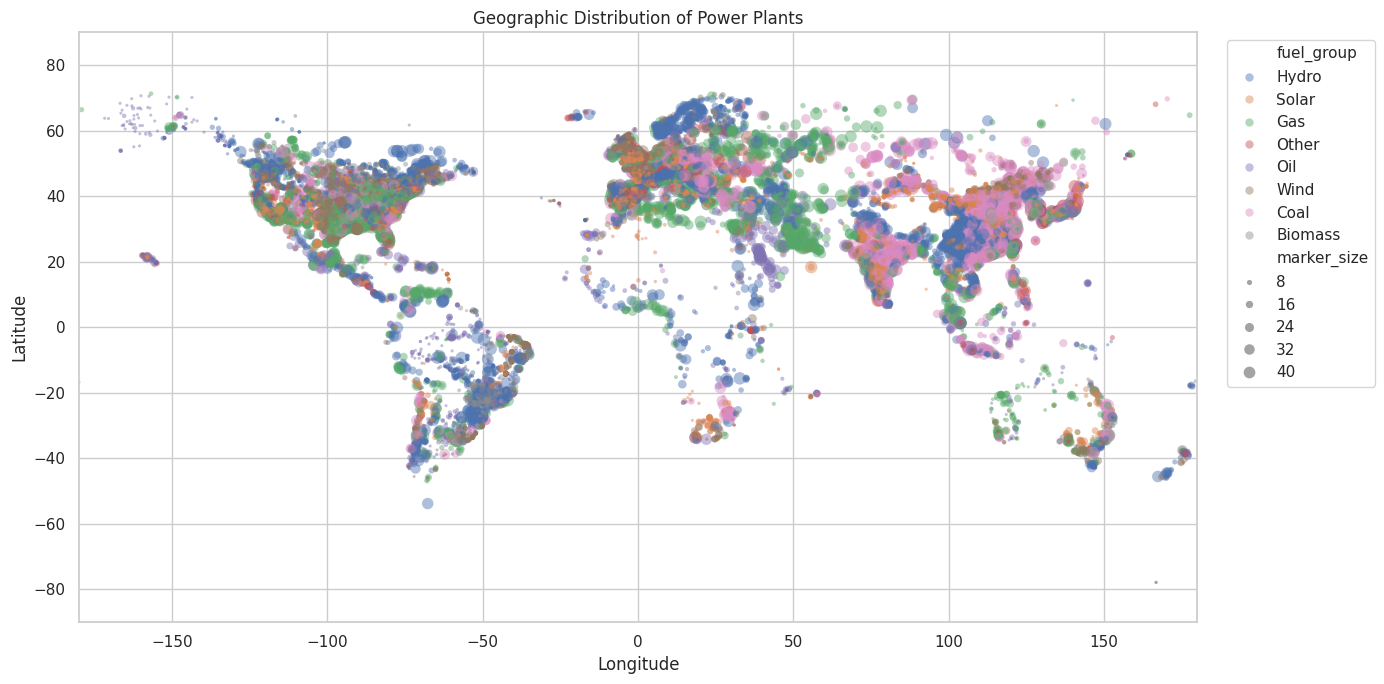

In [16]:
geo = df[["longitude", "latitude", "capacity_mw", "primary_fuel"]].dropna().copy()
geo["marker_size"] = np.clip(np.sqrt(geo["capacity_mw"].to_numpy()) * 1.4, 3, 45)

# Keep the most common fuels as named groups; combine the rest as Other.
top_geo_fuels = df["primary_fuel"].value_counts().head(7).index
geo["fuel_group"] = np.where(geo["primary_fuel"].isin(top_geo_fuels), geo["primary_fuel"], "Other")

plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=geo,
    x="longitude",
    y="latitude",
    hue="fuel_group",
    size="marker_size",
    sizes=(5, 80),
    alpha=0.45,
    linewidth=0,
    legend="brief"
)
plt.title("Geographic Distribution of Power Plants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 7. Matrix Operations, Eigenvalues, and Eigenvectors

A matrix can represent several quantitative attributes at once. Here, capacity, latitude, longitude, and commissioning year are standardized so they are on comparable scales.

The correlation matrix can then be constructed with matrix multiplication:

\[
R = \frac{Z^T Z}{n}
\]

where `Z` is the standardized data matrix. Eigenvalues and eigenvectors of this matrix describe directions of maximum multivariate variation. This is the mathematical foundation of Principal Component Analysis (PCA).


,capacity_mw,latitude,longitude,commissioning_year
capacity_mw,1.00,0.01,0.34,-0.01
latitude,0.01,1.00,-0.10,-0.15
longitude,0.34,-0.10,1.00,-0.02
commissioning_year,-0.01,-0.15,-0.02,1.00


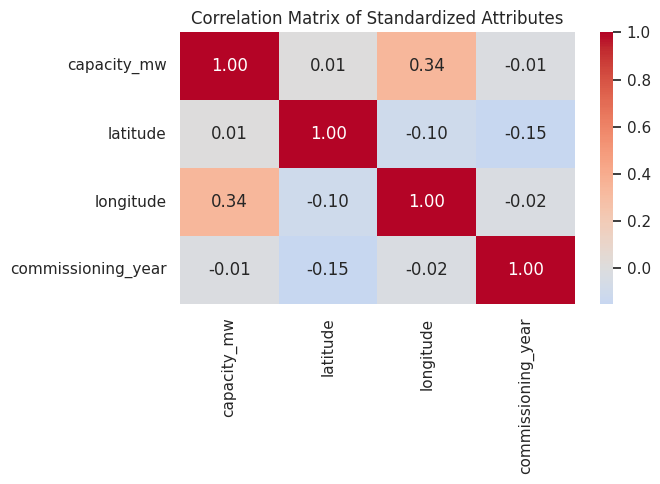

In [17]:
matrix_df = df[["capacity_mw", "latitude", "longitude", "commissioning_year"]].copy()
matrix_df = matrix_df[matrix_df["commissioning_year"].between(1800, 2026)].dropna()

X = matrix_df.to_numpy(dtype=float)
means = X.mean(axis=0)
stds = X.std(axis=0, ddof=0)
Z = (X - means) / stds

# Correlation matrix via matrix multiplication.
R = (Z.T @ Z) / len(Z)
R_df = pd.DataFrame(R, index=matrix_df.columns, columns=matrix_df.columns)
display(R_df.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(R_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Standardized Attributes")
plt.tight_layout()
plt.show()


In [18]:
# Eigen decomposition of the symmetric correlation matrix.
eigenvalues, eigenvectors = np.linalg.eigh(R)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
explained_ratio = eigenvalues / eigenvalues.sum()

eigen_table = pd.DataFrame({
    "eigenvalue": eigenvalues,
    "explained_variance_ratio": explained_ratio,
    "cumulative_ratio": np.cumsum(explained_ratio)
}, index=[f"Component {i}" for i in range(1, len(eigenvalues)+1)])

display(eigen_table)

loadings = pd.DataFrame(
    eigenvectors,
    index=matrix_df.columns,
    columns=[f"Component {i}" for i in range(1, len(eigenvalues)+1)]
)
print("Eigenvector loadings:")
display(loadings.round(3))


,eigenvalue,explained_variance_ratio,cumulative_ratio
Component 1,1.35,0.34,0.34
Component 2,1.15,0.29,0.63
Component 3,0.86,0.21,0.84
Component 4,0.64,0.16,1.00


Eigenvector loadings:


,Component 1,Component 2,Component 3,Component 4
capacity_mw,0.68,0.17,0.29,0.65
latitude,-0.19,0.69,0.65,-0.27
longitude,0.71,0.03,-0.11,-0.70
commissioning_year,0.01,-0.70,0.70,-0.13


### Why eigenvalues/eigenvectors matter here

- **Eigenvectors** identify combinations of attributes that move together.
- **Eigenvalues** show how much of the total standardized variance each direction explains.
- The first component captures the largest available multivariate pattern; later components capture progressively smaller independent patterns.
- In a real energy-analytics project, the same idea could reduce many correlated plant attributes into a smaller number of dimensions before clustering or machine-learning models.

A correlation or eigenvector loading should **not** automatically be interpreted as causation. Geographic patterns can reflect where countries, technologies, and database coverage are concentrated.


## 8. Integrating NumPy with Pandas and Matplotlib

NumPy is especially useful when the work requires fast, vectorized array logic that can be fed back into a Pandas DataFrame or visualization.


In [19]:
# Example 1: Complex NumPy filtering inside a Pandas workflow.
renewable_fuels = np.array(["Solar", "Wind", "Hydro", "Geothermal", "Biomass", "Wave and Tidal"])
renewable_mask = np.isin(df["primary_fuel"].to_numpy(), renewable_fuels)
capacity_90th = np.percentile(df["capacity_mw"].to_numpy(), 90)
large_mask = df["capacity_mw"].to_numpy() >= capacity_90th

large_renewables = df.loc[np.logical_and(renewable_mask, large_mask),
                          ["country_long", "name", "primary_fuel", "capacity_mw"]]

print(f"90th percentile capacity: {capacity_90th:,.1f} MW")
print(f"Large renewable plants found: {len(large_renewables):,}")
display(large_renewables.sort_values("capacity_mw", ascending=False).head(10))


90th percentile capacity: 433.6 MW
Large renewable plants found: 589


,country_long,name,primary_fuel,capacity_mw
8453,China,Three Gorges Dam,Hydro,"22,500.00"
5137,China,Baihetan Dam,Hydro,"13,050.00"
8755,China,Xiluodu,Hydro,"12,600.00"
34668,Venezuela,Simon Bolivar (Guri),Hydro,"8,851.00"
3272,Brazil,Tucuruí,Hydro,"8,535.00"
2197,Brazil,Itaipu (Parte Brasileira),Hydro,"7,000.00"
18280,Paraguay,Itaipu Binacional Dam (Paraguay part),Hydro,"7,000.00"
28190,United States of America,Grand Coulee,Hydro,"6,809.00"
8707,China,Xiangjiaba,Hydro,"6,448.00"
7447,China,Longtan,Hydro,"6,300.00"


,name,country_long,primary_fuel,capacity_mw,capacity_zscore
8453,Three Gorges Dam,China,Hydro,"22,500.00",45.62
5137,Baihetan Dam,China,Hydro,"13,050.00",26.32
8755,Xiluodu,China,Hydro,"12,600.00",25.40
19603,Surgutskaya GRES-2,Russia,Gas,"8,865.00",17.77
34668,Simon Bolivar (Guri),Venezuela,Hydro,"8,851.00",17.74
3272,Tucuruí,Brazil,Hydro,"8,535.00",17.10
16625,Kashiwazaki Kariwa,Japan,Nuclear,"8,212.00",16.44
2197,Itaipu (Parte Brasileira),Brazil,Hydro,"7,000.00",13.96
5703,East Hope Metals Wucaiwan power station,China,Coal,"7,000.00",13.96
18280,Itaipu Binacional Dam (Paraguay part),Paraguay,Hydro,"7,000.00",13.96


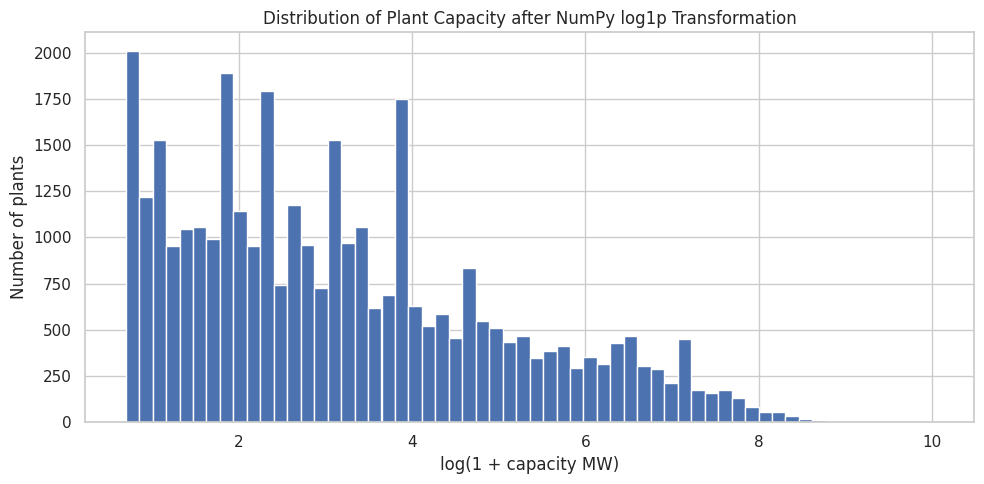

In [20]:
# Example 2: Use NumPy to compute capacity z-scores, then visualize them with Matplotlib.
cap = df["capacity_mw"].to_numpy(dtype=float)
capacity_z = (cap - np.mean(cap)) / np.std(cap)
df["capacity_zscore"] = capacity_z

# Extreme positive z-scores reveal unusually large plants.
extreme = df.nlargest(12, "capacity_zscore")[["name", "country_long", "primary_fuel", "capacity_mw", "capacity_zscore"]]
display(extreme)

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(cap), bins=60)
plt.title("Distribution of Plant Capacity after NumPy log1p Transformation")
plt.xlabel("log(1 + capacity MW)")
plt.ylabel("Number of plants")
plt.tight_layout()
plt.show()


## 9. Key Findings

1. **The database contains 34,936 plants.** Solar is the most common primary fuel by plant count, followed by hydro and wind.
2. **Plant capacity is extremely right-skewed.** The overall mean is about **163 MW**, while the median is only about **16.7 MW**. A small number of very large facilities pull the mean upward.
3. **Fuel type is strongly related to plant size.** Nuclear plants have the highest mean capacity (about **2,092 MW**), followed by coal (about **844 MW**) and gas (about **373 MW**). Solar has many facilities but a much smaller mean plant size (about **17.7 MW**).
4. **Capacity differs significantly among fuel types.** The multi-group ANOVA and the non-parametric Kruskal–Wallis test both produce p-values far below 0.05. The ANOVA eta-squared is approximately **0.28**, meaning fuel category accounts for a substantial share of capacity variation in this dataset.
5. **Coal and gas differ clearly in mean plant capacity.** Coal averages about **844 MW** compared with about **373 MW** for gas; the Welch test is highly significant.
6. **The recorded commissioning mix changes over time.** In the 2010s, solar and wind make up a much larger share of newly recorded plants than in older decades. This should be interpreted as a trend in recorded plant commissioning, not necessarily in total electricity produced.
7. **Geographic distribution is uneven.** The United States has the largest number of plant records, while China has the greatest total installed capacity in the database. These patterns also help explain why geography can appear in the multivariate matrix analysis.
8. **The first eigenvector explains roughly one-third of standardized variance.** Capacity and longitude contribute strongly to that first direction, but this is a multivariate pattern, not evidence that longitude causes plant size.

## Limitations

- `commissioning_year` is missing for roughly half of the plants, so historical trend analysis is based only on known years.
- The annual `generation_gwh_*` variables have extensive missingness. Installed capacity is therefore more suitable for consistent global comparisons in this report.
- Plant **counts** are not the same as electricity **generation**. Thousands of small solar facilities can outnumber a smaller set of very large coal, gas, hydro, or nuclear plants.
- This is an observational global database assembled from multiple sources, so country coverage and reporting practices can affect comparisons.

## Conclusion

NumPy, Pandas, Matplotlib, and Seaborn complement each other well for this dataset. Pandas provides the table-oriented cleaning and grouping operations, NumPy supplies efficient numerical filtering, transformations, matrix multiplication, and eigen decomposition, while Matplotlib/Seaborn make the statistical and geographical patterns visible. The strongest overall result is that the global power-plant landscape contains a very large number of small renewable installations alongside a smaller number of much larger conventional and nuclear facilities, with the reported commissioning mix shifting strongly toward solar and wind in more recent decades.
